In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root:", project_root)

Project Root: /home/akash/Projects/Altrodav


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data, split_data
from src.features import (
    build_preprocessor,
    fit_preprocessor,
    transform_data
)

from src.model import (
    build_model,
    train_model
)

from src.evaluate import (
    evaluate_model,
    detailed_evaluation,
    binary_metrics
)

In [3]:
df = load_data()

print("Original Shape:", df.shape)

df.head()

Original Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df["target"] = (df["target"] == 2).astype(int)

print(df["target"].value_counts())

df.head()

target
0    100
1     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print("Training :", X_train.shape)
print("Validation:", X_val.shape)
print("Test :", X_test.shape)

Training : (105, 4)
Validation: (22, 4)
Test : (23, 4)


In [6]:
numerical_features = X_train.columns.tolist()

preprocessor = build_preprocessor(numerical_features)

preprocessor = fit_preprocessor(
    preprocessor,
    X_train
)

print("Preprocessor Ready!")

Preprocessor Ready!


In [7]:
X_train = transform_data(preprocessor, X_train)

X_val = transform_data(preprocessor, X_val)

X_test = transform_data(preprocessor, X_test)

print("Data transformed successfully!")

Data transformed successfully!


In [8]:
model = build_model()

model = train_model(
    model,
    X_train,
    y_train
)

print(model)

LogisticRegression(max_iter=200, random_state=42)


In [9]:
accuracy = evaluate_model(
    model,
    X_val,
    y_val
)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9091


In [10]:
metrics = binary_metrics(
    model,
    X_val,
    y_val
)

print("Precision :", metrics["precision"])

print("Recall :", metrics["recall"])

print("F1 Score :", metrics["f1"])

print("ROC AUC :", metrics["roc_auc"])

Precision : 1.0
Recall : 0.7142857142857143
F1 Score : 0.8333333333333334
ROC AUC : 1.0


In [11]:
predictions, cm, report = detailed_evaluation(
    model,
    X_val,
    y_val
)

print("Confusion Matrix\n")

print(cm)

Confusion Matrix

[[15  0]
 [ 2  5]]


In [12]:
print(report)

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.71      0.83         7

    accuracy                           0.91        22
   macro avg       0.94      0.86      0.89        22
weighted avg       0.92      0.91      0.90        22



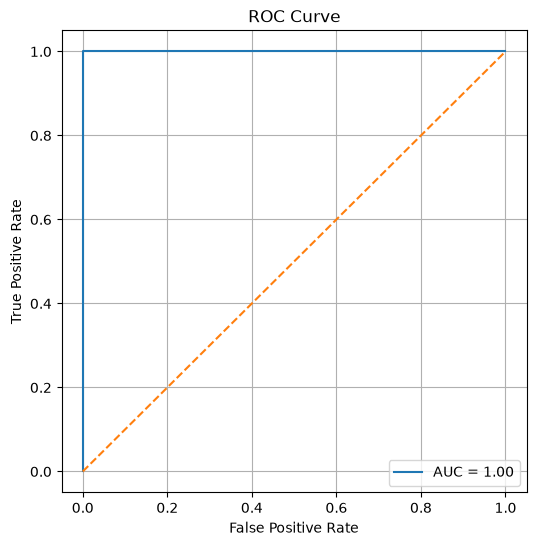

In [13]:
plt.figure(figsize=(6,6))

plt.plot(
    metrics["fpr"],
    metrics["tpr"],
    label=f"AUC = {metrics['roc_auc']:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

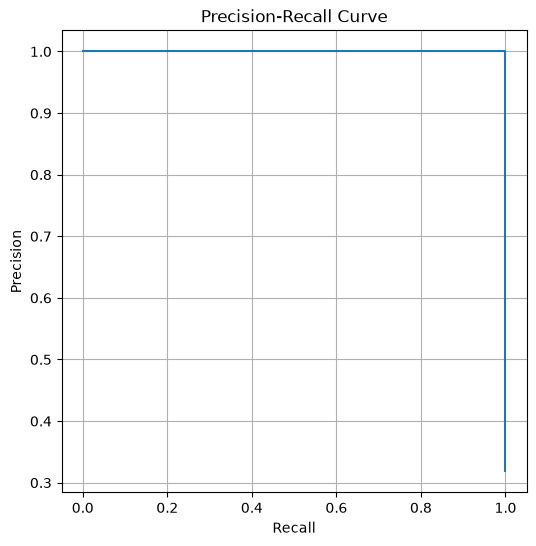

In [14]:
plt.figure(figsize=(6,6))

plt.plot(
    metrics["pr_recall"],
    metrics["pr_precision"]
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [15]:
threshold = 0.50

print(f"Current Threshold : {threshold}")

print()

print("Recommendation:")

print(
    "For this balanced Iris dataset, "
    "0.50 is an appropriate threshold."
)

Current Threshold : 0.5

Recommendation:
For this balanced Iris dataset, 0.50 is an appropriate threshold.


In [16]:
import os

os.makedirs("../logs", exist_ok=True)

log = pd.DataFrame({

    "Model": ["Binary Logistic Regression"],

    "Accuracy": [accuracy],

    "Precision": [metrics["precision"]],

    "Recall": [metrics["recall"]],

    "F1": [metrics["f1"]],

    "ROC_AUC": [metrics["roc_auc"]]

})

log.to_csv(
    "../logs/task06_binary_results.csv",
    index=False
)

print("Experiment Saved!")

Experiment Saved!


In [17]:
print("========== TASK 06 SUMMARY ==========")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {metrics['precision']:.4f}")

print(f"Recall : {metrics['recall']:.4f}")

print(f"F1 Score : {metrics['f1']:.4f}")

print(f"ROC AUC : {metrics['roc_auc']:.4f}")

print()

print("Task 6 completed successfully!")

========== TASK 06 SUMMARY ==========
Accuracy : 0.9091
Precision : 1.0000
Recall : 0.7143
F1 Score : 0.8333
ROC AUC : 1.0000

Task 6 completed successfully!
